## Checking of Energy Minimization

In [1]:
import os
data_dir = "/home/daneel/gitrepos"
data_dir = os.path.join(data_dir, "gromacs_sims/Antimicrobial_Peptides/Ku04AMP01_Membrane_Bilayer/simulation_perp")
os.chdir(data_dir)


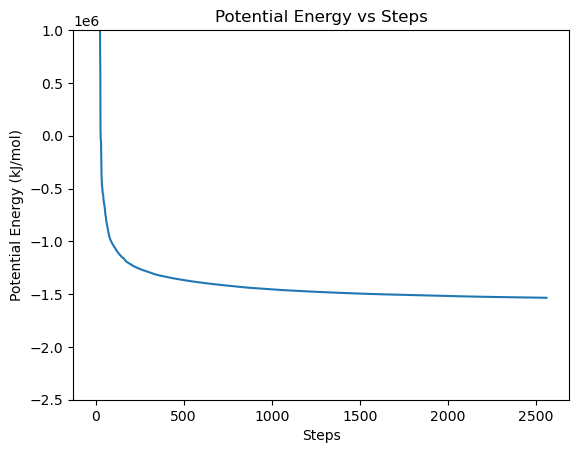

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Load data, skipping lines starting with '@' and '#'
# unpack=True allows you to assign columns directly to x and y
x, y = np.loadtxt("potential.xvg", comments=["@", "#"], unpack=True)

plt.plot(x, y)
plt.title("Potential Energy vs Steps")
plt.xlabel("Steps")
plt.ylabel("Potential Energy (kJ/mol)")
plt.ylim(-2500000, 1000000)  # Set y-axis limits for better visualization
plt.show()

In [3]:
import shutil

# Resolve gmx binary: prefer PATH, fall back to known conda/venv locations
GMX = shutil.which("gmx") or shutil.which("gmx_mpi")
if GMX is None:
    for candidate in [
        "/venv/main/bin.AVX2_256/gmx",
        "/venv/main/bin/gmx",
        "/usr/local/bin/gmx",
    ]:
        if os.path.isfile(candidate):
            GMX = candidate
            break
if GMX is None:
    raise RuntimeError("gmx binary not found — set PATH or add the correct path to the candidate list above")
print(f"Using gmx: {GMX}")

Using gmx: /usr/local/bin/gmx


## Equilibration Plots

In [10]:
import subprocess
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

sim_dir = os.path.dirname(os.path.abspath("step6.1.xtc"))  # notebook working dir

# Derive .edr files from .xtc files (gmx energy reads .edr, not .xtc)
xtc_files = sorted(glob.glob("step6.*.xtc"))
edr_files = [f.replace(".xtc", ".edr") for f in xtc_files]

all_time = []
all_temp = []
all_press = []
step_labels = []

for edr_file, xtc_file in zip(edr_files, xtc_files):
    if not os.path.exists(edr_file):
        print(f"Warning: {edr_file} not found, skipping.")
        continue

    step_name = os.path.splitext(edr_file)[0]  # e.g. "step6.1"
    xvg_file = f"{step_name}_tp.xvg"

    result = subprocess.run(
        [GMX, "energy", "-f", edr_file, "-o", xvg_file],
        input=b"Temperature\nPressure\n0\n",
        capture_output=True,
    )

    if result.returncode != 0:
        print(f"gmx energy failed for {edr_file}:")
        print(result.stderr.decode(errors="replace"))
        continue
    else:
        print(f"Processed {edr_file} -> {xvg_file}")

    # xvg columns: time, Temperature, Pressure
    try:
        data = np.loadtxt(xvg_file, comments=["@", "#"], unpack=True)
    except Exception as e:
        print(f"Could not load {xvg_file}: {e}")
        continue

    all_time.append(data[0])
    all_temp.append(data[1])
    all_press.append(data[2])
    step_labels.append(step_name)

print(f"\nLoaded data for steps: {step_labels}")


Processed step6.1.edr -> step6.1_tp.xvg
Processed step6.2.edr -> step6.2_tp.xvg
Processed step6.3.edr -> step6.3_tp.xvg
Processed step6.4.edr -> step6.4_tp.xvg
Processed step6.5.edr -> step6.5_tp.xvg
Processed step6.6.edr -> step6.6_tp.xvg

Loaded data for steps: ['step6.1', 'step6.2', 'step6.3', 'step6.4', 'step6.5', 'step6.6']


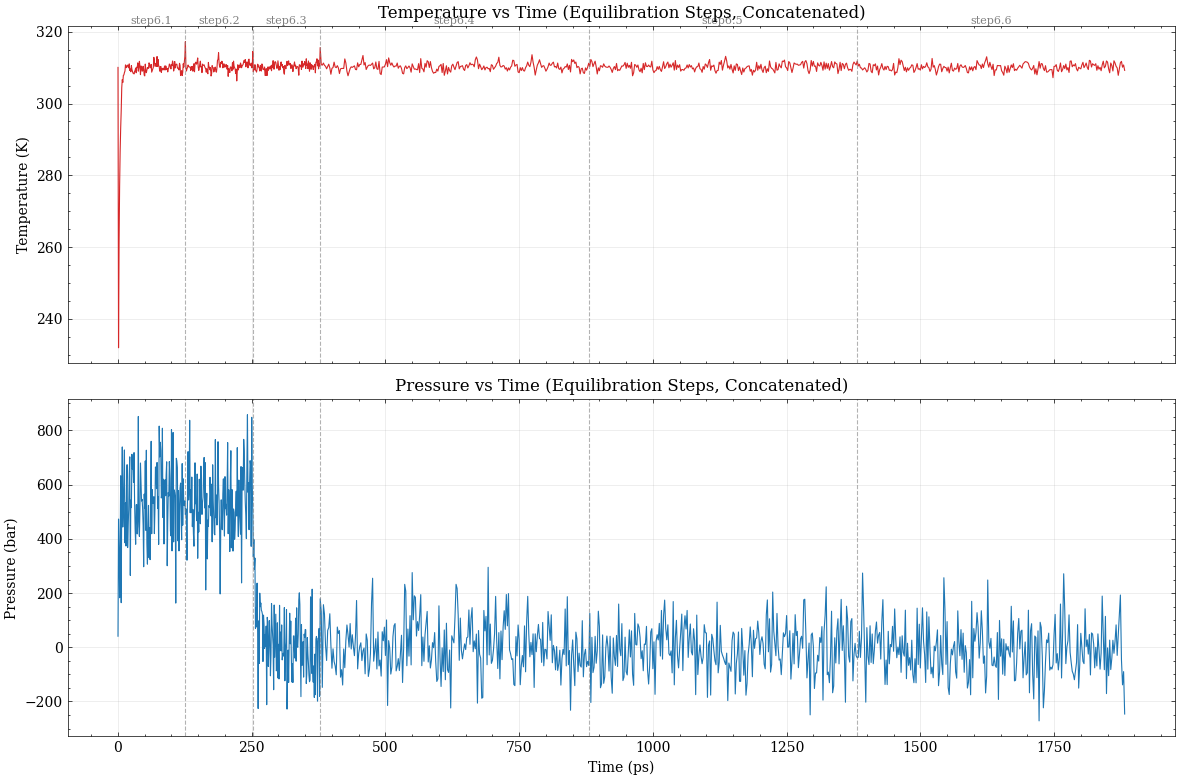

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use("science")
plt.rcParams['text.usetex'] = False
# Concatenate consecutive steps into a single continuous time series
# Offset each step's time so it follows the previous one
concat_time = []
concat_temp = []
concat_press = []
time_offset = 0.0

for time, temp, press in zip(all_time, all_temp, all_press):
    concat_time.append(time + time_offset)
    concat_temp.append(temp)
    concat_press.append(press)
    time_offset += time[-1] - time[0] + (time[1] - time[0])  # advance by step duration + dt

concat_time = np.concatenate(concat_time)
concat_temp = np.concatenate(concat_temp)
concat_press = np.concatenate(concat_press)

# Add vertical lines at step boundaries
step_boundaries = []
t_offset = 0.0
for time in all_time[:-1]:
    t_offset += time[-1] - time[0] + (time[1] - time[0])
    step_boundaries.append(t_offset)

fig, (ax_temp, ax_press) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax_temp.plot(concat_time, concat_temp, lw=0.8, color="tab:red")
ax_press.plot(concat_time, concat_press, lw=0.8, color="tab:blue")

for bnd in step_boundaries:
    ax_temp.axvline(bnd, color="gray", lw=0.8, ls="--", alpha=0.6)
    ax_press.axvline(bnd, color="gray", lw=0.8, ls="--", alpha=0.6)

# Annotate step labels at the top of the temperature plot
t_offset = 0.0
for i, (time, label) in enumerate(zip(all_time, step_labels)):
    mid = t_offset + (time[-1] - time[0]) / 2
    ax_temp.text(mid, ax_temp.get_ylim()[1], label, ha="center", va="bottom",
                 fontsize=8, color="gray")
    t_offset += time[-1] - time[0] + (time[1] - time[0])

ax_temp.set_title("Temperature vs Time (Equilibration Steps, Concatenated)")
ax_temp.set_ylabel("Temperature (K)")
ax_temp.grid(True, alpha=0.3)

ax_press.set_title("Pressure vs Time (Equilibration Steps, Concatenated)")
ax_press.set_xlabel("Time (ps)")
ax_press.set_ylabel("Pressure (bar)")
ax_press.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Box vectors

It is also advisable to verify that the box vectors have stabilized, ensuring a stable lateral area of the membrane (Box-X and Box-Y).

Note that box vectors only change during NPT ensemble dynamics. in NVT ensemble, all boundary conditions are fixed by definition.

Processed step6.3.edr -> step6.3_box.xvg
Processed step6.4.edr -> step6.4_box.xvg
Processed step6.5.edr -> step6.5_box.xvg
Processed step6.6.edr -> step6.6_box.xvg


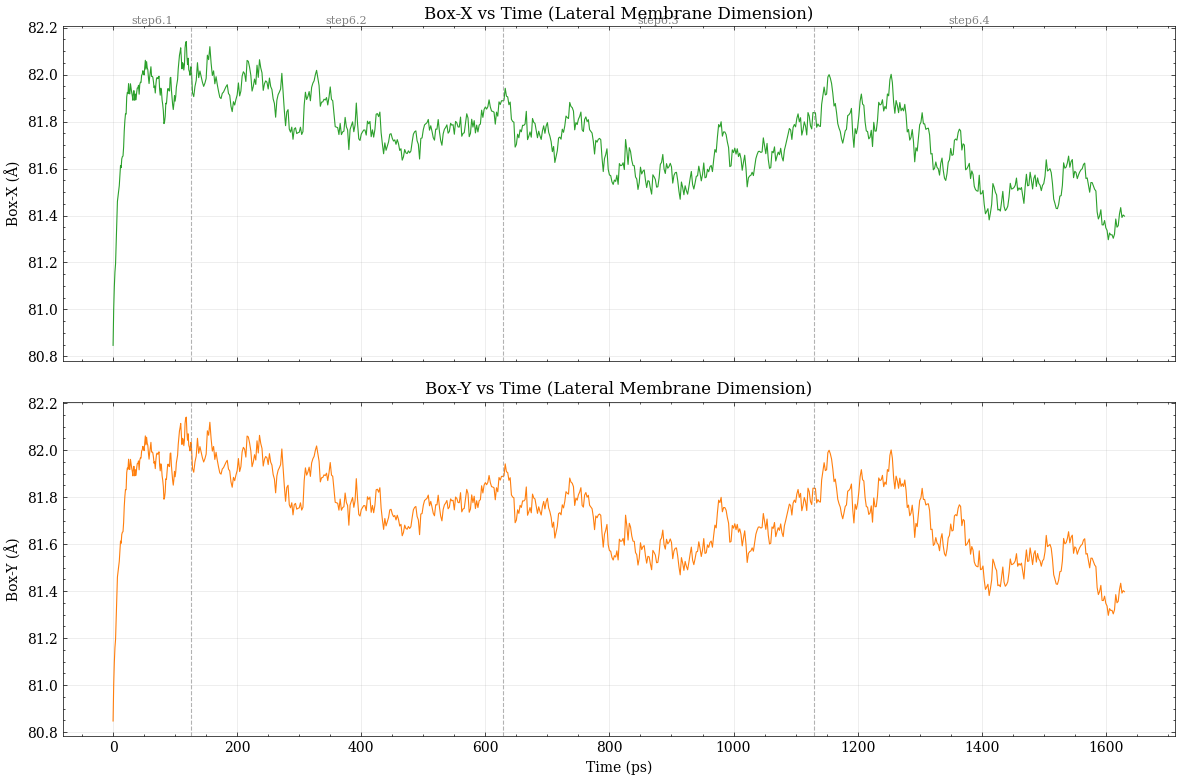

In [13]:
import subprocess
import os
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use("science")
plt.rcParams['text.usetex'] = False
# Extract Box-X and Box-Y from each equilibration step .edr file
all_box_time = []
all_boxx = []
all_boxy = []

for edr_file in edr_files[2:]:
    step_name = os.path.splitext(edr_file)[0]
    xvg_file = f"{step_name}_box.xvg"

    result = subprocess.run(
        [GMX, "energy", "-f", edr_file, "-o", xvg_file],
        input=b"Box-X\nBox-Y\n0\n",
        capture_output=True,
    )

    if result.returncode != 0:
        print(f"gmx energy failed for {edr_file}:")
        print(result.stderr.decode(errors="replace"))
        continue
    else:
        print(f"Processed {edr_file} -> {xvg_file}")

    try:
        data = np.loadtxt(xvg_file, comments=["@", "#"], unpack=True)
    except Exception as e:
        print(f"Could not load {xvg_file}: {e}")
        continue

    # data[0]=time (ps), data[1]=Box-X (nm), data[2]=Box-Y (nm)
    all_box_time.append(data[0])
    all_boxx.append(data[1])
    all_boxy.append(data[2])

# Build concatenated time axis independently for box data
concat_box_time = []
box_time_offset = 0.0
for t in all_box_time:
    dt = t[1] - t[0] if len(t) > 1 else 0.0
    concat_box_time.append(t + box_time_offset)
    box_time_offset += t[-1] - t[0] + dt

concat_box_time = np.concatenate(concat_box_time)
concat_boxx = np.concatenate(all_boxx)
concat_boxy = np.concatenate(all_boxy)

# Step boundary positions on this time axis
box_boundaries = []
t_off = 0.0
for t in all_box_time[:-1]:
    dt = t[1] - t[0] if len(t) > 1 else 0.0
    t_off += t[-1] - t[0] + dt
    box_boundaries.append(t_off)

# Plot
fig, (ax_x, ax_y) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax_x.plot(concat_box_time, concat_boxx * 10, lw=0.8, color="tab:green")   # nm -> Å
ax_y.plot(concat_box_time, concat_boxy * 10, lw=0.8, color="tab:orange")

for bnd in box_boundaries:
    ax_x.axvline(bnd, color="gray", lw=0.8, ls="--", alpha=0.6)
    ax_y.axvline(bnd, color="gray", lw=0.8, ls="--", alpha=0.6)

# Step labels
t_off = 0.0
for t, label in zip(all_box_time, step_labels):
    dt = t[1] - t[0] if len(t) > 1 else 0.0
    mid = t_off + (t[-1] - t[0]) / 2
    ax_x.text(mid, ax_x.get_ylim()[1], label, ha="center", va="bottom",
              fontsize=8, color="gray")
    t_off += t[-1] - t[0] + dt

ax_x.set_title("Box-X vs Time (Lateral Membrane Dimension)")
ax_x.set_ylabel("Box-X (Å)")
ax_x.grid(True, alpha=0.3)

ax_y.set_title("Box-Y vs Time (Lateral Membrane Dimension)")
ax_y.set_xlabel("Time (ps)")
ax_y.set_ylabel("Box-Y (Å)")
ax_y.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Production PP

First, let's test to ensure that the concatenation worked.

In [20]:
import MDAnalysis as mda


#u = mda.Universe(os.path.join(data_dir, "step7_1.tpr"), os.path.join(data_dir, "traj_prod.xtc"),os.path.join(data_dir, "step7_11_100ns.part0002.xtc"))
u = mda.Universe("step7_1.tpr", "traj_nojump.xtc")

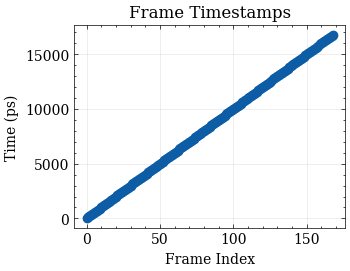

Min dt: 100.00 ps, Max dt: 100.00 ps
Monotonically increasing: True
Total frames: 169, Time range: 0.00 – 16800.00 ps


In [21]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use("science")
plt.rcParams['text.usetex'] = False
# First, check the timestamps for each frame
timestamps = [ts.time for ts in u.trajectory]  # in ps

plt.plot(timestamps, marker="o", linestyle="")
plt.title("Frame Timestamps")
plt.xlabel("Frame Index")
plt.ylabel("Time (ps)")
plt.grid(True, alpha=0.3)
plt.show()

# Check if timestamps are monotonically increasing (expected after correct trjcat)
import numpy as np
diffs = np.diff(timestamps)
print(f"Min dt: {diffs.min():.2f} ps, Max dt: {diffs.max():.2f} ps")
print(f"Monotonically increasing: {np.all(diffs > 0)}")
print(f"Total frames: {len(timestamps)}, Time range: {timestamps[0]:.2f} – {timestamps[-1]:.2f} ps")

The concatenation succeeded!

In [22]:
corrected_times = np.array(timestamps)
print(f"Mapped Time Range: {corrected_times[0]:.0f} to {corrected_times[-1]:.0f} ps")

Mapped Time Range: 0 to 16800 ps


## Verify that membrane is oriented with z-axis vertical


Although this is standard convention, we **should** check this.


The definitive check is a number density profile — if z is the normal, you'll see distinct layers (water → LPS headgroups → acyl chains → phospholipid headgroups → water) along z but not along x or y. Add this cell to confirm:

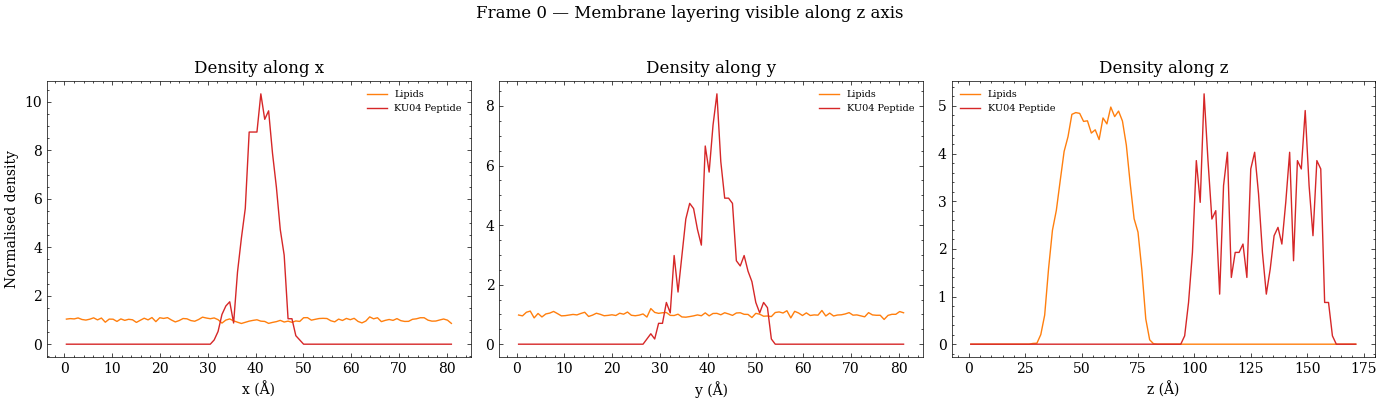

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use("science")
plt.rcParams['text.usetex'] = False
u.trajectory[0]
bins = 100

# Updated selections based on topol.top
sel_lip = u.select_atoms("resname POPE OYPE PYPG PVCL2 PMPE QMPE PMPG CHOL")
sel_ku04 = u.select_atoms("not (resname POPE OYPE PYPG PVCL2 PMPE QMPE PMPG CHOL W WF SOL ION NA SOD CL CLA TIP3)")

box = u.dimensions[:3] # Å

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
labels = ["x", "y", "z"]

# Components to plot
components = [
    (sel_lip, "Lipids", "tab:orange"),
    (sel_ku04, "KU04 Peptide", "tab:red"),
]

for col, (ax, dim) in enumerate(zip(axes, range(3))):
    for ag, name, color in components:
        if len(ag) == 0:
            continue
        
        pos = ag.positions[:, dim]
        counts, edges = np.histogram(pos, bins=bins, range=(0, box[dim]))
        centres = 0.5 * (edges[:-1] + edges[1:])
        
        # Avoid division by zero if a component is missing in a specific plane (unlikely for density)
        if counts.max() > 0:
            ax.plot(centres, counts / counts.mean(), label=name, lw=1.0, color=color)

    ax.set_xlabel(f"{labels[col]} (Å)")
    ax.set_ylabel("Normalised density" if col == 0 else "")
    #ax.set_ylim(0, 1.5)
    ax.set_title(f"Density along {labels[col]}")
    ax.legend(fontsize=7)

plt.suptitle("Frame 0 — Membrane layering visible along z axis", y=1.02)
plt.tight_layout()
plt.show()

The lipid layers are uniform in x and y, and the ku04 partially went into the lipid during energy minim.

## Get RMSDs

- **Old code (no superposition)**: RMSD starts at ~138 Å and stays 138–145 Å — the entire signal is a **PBC artifact**. The membrane's center of mass jumped across the periodic box at some point (very common with broken `trjcat` trajectories), so the raw atom-to-atom distances are dominated by that ~138 Å offset, not by conformational changes.

- **New code (`superposition=True`)**: Least-squares fits (translates + rotates) the membrane onto the reference before computing RMSD, removing the rigid-body offset. The result (0–30 Å) is the actual conformational RMSD.

So the old plot was physically meaningless. The new one is correct.

That said, the spikiness in the new plot is still a concern — it's a sign of residual PBC imaging issues (individual molecules jumping across box boundaries within the concatenated trajectory). For a membrane, the standard fix is to also **unwrap** molecules per-frame before computing RMSD: 

The `transformations.unwrap` call fixes atoms that jump across the periodic boundary mid-trajectory, which is what causes those sharp spikes. It runs on-the-fly for each frame without modifying the file on disk.

Made changes.

In [30]:
import os
from multiprocessing import Pool, cpu_count
from functools import partial
from MDAnalysis.analysis import rms
from MDAnalysis import transformations as trans
from tqdm.notebook import tqdm
import numpy as np
# --- Config ---
tpr_file = os.path.join(data_dir, "step7_1.tpr")
xtc_file = os.path.join(data_dir, "traj_nojump.xtc")

# If using martini, select by exclusion of standard Martini 3 membrane, water, and ion residues
# Example: ku04_sel = "not (resname POPE OYPE PYPG PVCL2 DPPE DPPG CHOL W WF SOL ION NA SOD CL CLA TIP3)"
#ku04_sel = "resindex 0-35" 
ku04_sel = "not (resname POPE OYPE PYPG PVCL2 PMPE QMPE PMPG CHOL W WF SOL ION NA SOD CL CLA TIP3)"

# If using martini, select by inclusion of standard Martini 3 membrane residues
# Example: memb_sel = "resname POPE OYPE PYPG PVCL2 DPPE DPPG"
#memb_sel = "resindex 36-235"
memb_sel = "resname POPE OYPE PYPG PVCL2 PMPE QMPE PMPG CHOL"
# Reload universe with center_in_box + wrap (no unwrap: that needs sequential
# reads from frame 0 and is incompatible with block-parallel random access).
# traj_whole.xtc is already molecule-whole, so this is sufficient.
u = mda.Universe(tpr_file, xtc_file)
membrane = u.select_atoms(memb_sel)
ku04     = u.select_atoms(ku04_sel)
workflow = [
    trans.center_in_box(membrane, wrap=False),
    #trans.wrap(u.select_atoms("all"), compound="residues"),
]
u.trajectory.add_transformations(*workflow)

# Reference = frame 0 after imaging
u.trajectory[0]
ref_memb = membrane.positions.copy()
ref_ku04  = ku04.positions.copy()

# --- Split trajectory into blocks (one per core) ---
n_jobs   = min(cpu_count(), 8)
n_frames = u.trajectory.n_frames
n_fpb    = n_frames // n_jobs   # frames per block
blocks   = [range(i * n_fpb, (i + 1) * n_fpb) for i in range(n_jobs - 1)]
blocks.append(range((n_jobs - 1) * n_fpb, n_frames))
print(f"Frames: {n_frames}  |  Cores: {n_jobs}  |  ~{n_fpb} frames/block")

# --- Worker function ---
def rmsd_block(block_frames, tpr_file, xtc_file, memb_sel, ku04_sel, ref_memb, ref_ku04):
    """Each worker loads its own Universe and iterates its slice sequentially."""
    import MDAnalysis as mda
    from MDAnalysis.analysis import rms
    from MDAnalysis import transformations as trans

    u_w    = mda.Universe(tpr_file, xtc_file)
    memb_w = u_w.select_atoms(memb_sel)
    ku04_w = u_w.select_atoms(ku04_sel)
    wf = [
        trans.center_in_box(memb_w, wrap=False),
        # trans.wrap(u_w.select_atoms("all"), compound="residues"),
    ]
    u_w.trajectory.add_transformations(*wf)

    res_memb, res_ku04 = [], []
    for _ in u_w.trajectory[block_frames.start:block_frames.stop]:
        res_memb.append(rms.rmsd(memb_w.positions, ref_memb, superposition=True))
        res_ku04.append(rms.rmsd(ku04_w.positions,  ref_ku04,  superposition=True))
    u_w.trajectory.close() # Explicitly close to avoid __del__ race    
    return res_memb, res_ku04

# --- Run in parallel ---
run_block = partial(rmsd_block,
                    tpr_file=tpr_file, xtc_file=xtc_file,
                    memb_sel=memb_sel, ku04_sel=ku04_sel,
                    ref_memb=ref_memb, ref_ku04=ref_ku04)

with Pool(n_jobs) as pool:
    block_results = list(tqdm(pool.imap(run_block, blocks),
                            total=n_jobs, desc="Blocks", unit="block"))

# --- Combine in order ---
rmsd_memb = [v for memb_res, _       in block_results for v in memb_res]
rmsd_ku04  = [v for _,       ku04_res  in block_results for v in ku04_res]
print(f"Done. {len(rmsd_memb)} RMSD values computed.")

Frames: 169  |  Cores: 8  |  ~21 frames/block


Blocks:   0%|          | 0/8 [00:00<?, ?block/s]

Done. 169 RMSD values computed.


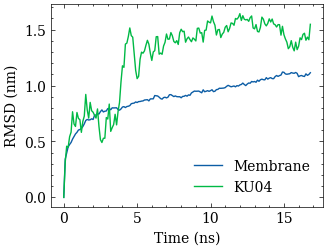

In [31]:
import scienceplots
plt.style.use("science")
plt.rcParams['text.usetex'] = False

plt.plot(corrected_times/1000, np.array(rmsd_memb)/10, label="Membrane")
plt.plot(corrected_times/1000, np.array(rmsd_ku04)/10, label="KU04")
plt.legend()
plt.xlabel("Time (ns)")
plt.ylabel("RMSD (nm)")
#plt.grid(True, alpha=0.6)
plt.show()

In [25]:
print(f"Atoms: {len(membrane)}")
print(f"Resnames: {np.unique(membrane.resnames)}")

Atoms: 24916
Resnames: ['OYPE' 'PMPE' 'PMPG' 'POPE' 'PVCL2' 'PYPG' 'QMPE']


## Peptide center-of-mass depth (MOST IMPORTANT)

This is the primary penetration metric.

Measure:

COM of PMBN
vs
membrane midplane (or phosphate plane).

Plot:

z_peptide(t) - z_membrane_center(t)

Interpretation:

* constant near-water value → no binding

* stable near-headgroup region → adsorption

* gradual inward motion → insertion

* crossing midplane → translocation

### Get headgroup distance 

You can verify the exact headgroup positions for your specific system by calculating the Z-position of the Phosphorus (P) atoms relative to the midplane.

In GROMACS/CHARMM36, Phosphorus atoms (name P) are located in the headgroups of all your lipids (PMPE, POPE, PYPG, etc.). By tracking their COM, you get the objective "surface" of the membrane.

In [32]:
# Selection for all phosphorus atoms in the membrane. When using martini CG, try replacing with "name PO4" for the phosphate beads
phosphorus_sel = "resname POPE OYPE PYPG PVCL2 PMPE QMPE PMPG CHOL and name P"

def p_depth_block(block_frames, tpr_file, xtc_file, memb_sel, p_sel):
    import MDAnalysis as mda
    from MDAnalysis import transformations as trans
    u_w = mda.Universe(tpr_file, xtc_file)
    memb_w = u_w.select_atoms(memb_sel)
    p_w = u_w.select_atoms(p_sel)
    
    # Imaging
    wf = [trans.center_in_box(memb_w, wrap=False), 
        #trans.wrap(u_w.atoms)
        ]
    u_w.trajectory.add_transformations(*wf)

    z_p_upper, z_p_lower, z_mid = [], [], []
    for _ in u_w.trajectory[block_frames.start:block_frames.stop]:
        mid = memb_w.center_of_mass()[2]
        p_pos = p_w.positions[:, 2]
        
        # Split P atoms into upper and lower based on midplane
        z_p_upper.append(p_pos[p_pos > mid].mean())
        z_p_lower.append(p_pos[p_pos < mid].mean())
        z_mid.append(mid)
        
    u_w.trajectory.close()
    return z_p_upper, z_p_lower, z_mid

# Run in parallel (reuse your blocks and n_jobs)
run_p = partial(p_depth_block, tpr_file=tpr_file, xtc_file=xtc_file,
                memb_sel=memb_sel, p_sel=phosphorus_sel)

with Pool(n_jobs) as pool:
    p_results = list(tqdm(pool.imap(run_p, blocks), total=n_jobs, desc="P-depth"))

# Average distances from midplane
dz_p_upper = np.array([v for r in p_results for v in r[0]]) - np.array([v for r in p_results for v in r[2]])
dz_p_lower = np.array([v for r in p_results for v in r[1]]) - np.array([v for r in p_results for v in r[2]])

print(f"Verified Phosphorus Planes: {dz_p_upper.mean():.2f} Å and {dz_p_lower.mean():.2f} Å")

P-depth:   0%|          | 0/8 [00:00<?, ?it/s]

Verified Phosphorus Planes: 18.96 Å and -18.98 Å


### Get z-COM of peptide

In [33]:
import numpy as np
from tqdm.notebook import tqdm
from functools import partial
from multiprocessing import Pool

def depth_block(block_frames, tpr_file, xtc_file, memb_sel, ku04_sel):
    """Worker: z-COM of KU04 and membrane midplane per frame."""
    import MDAnalysis as mda
    from MDAnalysis import transformations as trans

    u_w     = mda.Universe(tpr_file, xtc_file)
    memb_w  = u_w.select_atoms(memb_sel)
    ku04_w  = u_w.select_atoms(ku04_sel)
    
    # Standard imaging to ensure COM calculations aren't broken by PBC
    wf = [
        trans.center_in_box(memb_w, wrap=False),
       # trans.wrap(u_w.atoms, compound="residues"),
    ]
    u_w.trajectory.add_transformations(*wf)

    z_ku04, z_mid = [], []
    for _ in u_w.trajectory[block_frames.start:block_frames.stop]:
        z_mid.append(memb_w.center_of_mass()[2])
        z_ku04.append(ku04_w.center_of_mass()[2])
        
    u_w.trajectory.close()
    return z_ku04, z_mid

# Prepare partial function for parallel execution
run_depth = partial(depth_block,
                    tpr_file=tpr_file, xtc_file=xtc_file,
                    memb_sel=memb_sel, ku04_sel=ku04_sel)

print(f"Computing penetration depth on {n_jobs} cores …")
with Pool(n_jobs) as pool:
    depth_results = list(tqdm(pool.imap(run_depth, blocks),
                            total=n_jobs, desc="Blocks", unit="block"))

# Combine results
z_ku04 = np.array([v for r in depth_results for v in r[0]])
z_mid  = np.array([v for r in depth_results for v in r[1]])

# Depth relative to membrane midplane
# (positive = upper leaflet side, negative = lower leaflet side)
dz_ku04 = z_ku04 - z_mid

print(f"Done. Mean KU04 depth relative to midplane: {dz_ku04.mean():.1f} Å")

Computing penetration depth on 8 cores …


Blocks:   0%|          | 0/8 [00:00<?, ?block/s]

Done. Mean KU04 depth relative to midplane: 76.7 Å


### Plot z-COM relative to membrane COM and headgroup planes

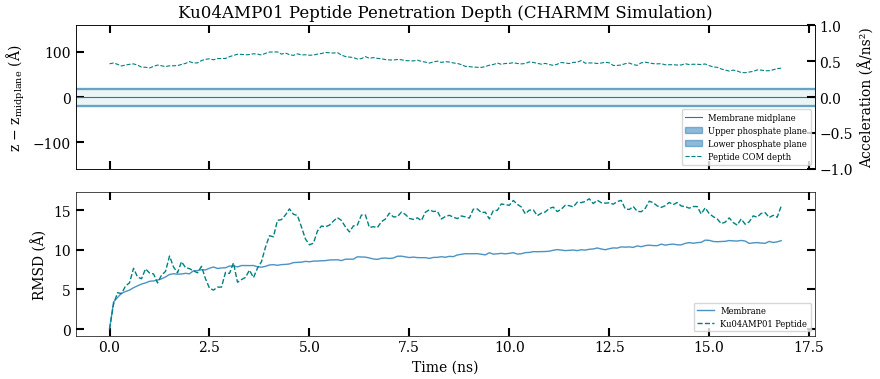

In [34]:
from scipy.interpolate import UnivariateSpline
import matplotlib.pyplot as plt
import scienceplots
plt.style.use("science")
plt.rcParams['text.usetex'] = False
t_ns = corrected_times / 1000

fig, (ax_up, ax_down) = plt.subplots(2, 1, figsize=(9, 4), sharex=True, tight_layout=True, gridspec_kw={'height_ratios': [1, 1]})


ax = ax_up  # Use the lower axis for plotting
# Mark the membrane center line
ax.axhline(0, color="tab:blue", lw=0.8, label="Membrane midplane")

# UPDATED: Verified Phosphorus headgroup planes
upper_p = dz_p_upper.mean()
lower_p = dz_p_lower.mean()

upper_p_std = dz_p_upper.std()
lower_p_std = dz_p_lower.std()
ax.axhspan(upper_p - upper_p_std, upper_p + upper_p_std, alpha=0.5, color="tab:blue", label="Upper phosphate plane")
ax.axhspan(lower_p - lower_p_std, lower_p + lower_p_std, alpha=0.5, color="tab:blue", label="Lower phosphate plane")

ax.axhspan(lower_p, upper_p, alpha=0.08, color="teal")

# Plot the Peptide depth
ax.plot(t_ns, dz_ku04, lw=0.8, color="teal", label="Peptide COM depth", ls="--")

ax.set_title("Ku04AMP01 Peptide Penetration Depth (CHARMM Simulation)")
ax.set_ylabel(r"z − z$_{\text{midplane}}$ (Å)")
ax.minorticks_off()
ax_ylim = np.sort(list(ax.get_ylim())) * 1.5
ax.set_ylim(-ax_ylim[1], ax_ylim[1])

# Add a secondary y-axis to show acceleration of penetration depth (optional)
ax2 = ax.twinx()
ax2.minorticks_off()

# Get derivativs after spline interpolation
#spline = UnivariateSpline(t_ns, dz_ku04, s=0)
#dz_ku04_dt = spline.derivative(n=1)(t_ns)
#dz_ku04_d2t = spline.derivative(n=2)(t_ns)

# Calculate mean and std over only the last 50% of the simulation
last_50_percent_mask = t_ns >= (t_ns[-1] - 0.5 * (t_ns[-1] - t_ns[0]))
#mean_accel_last_50_percent = dz_ku04_d2t[last_50_percent_mask].mean()
#std_accel_last_50_percent = dz_ku04_d2t[last_50_percent_mask].std()


#ax2.plot(t_ns, dz_ku04_d2t, lw=0.8, color="tab:green", alpha=0.5, label=f"z-Acceleration: Mean (last 50%) ({mean_accel_last_50_percent:.2f} ± {std_accel_last_50_percent:.2f}) Å/ns²", ls="-.")
#ax2.axhline(dz_ku04_d2t.mean(), color="gray", lw=0.8, ls="--", alpha=0.1)
ax2.set_ylabel(r"Acceleration (Å/ns²)")
# Align the zeros of ax and ax2
ax2_ylim = np.sort(list(ax2.get_ylim()))
ax2.set_ylim(-ax2_ylim[1], ax2_ylim[1])

# Combine legends from both axes
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="lower right", fontsize=6, frameon=True, fancybox=True)


ax = ax_down
ax.minorticks_off()
ax.set_xlabel("Time (ns)")
ax.plot(t_ns, np.array(rmsd_memb), label="Membrane", alpha=0.8, color="tab:blue")
ax.plot(t_ns, np.array(rmsd_ku04), label="Ku04AMP01 Peptide", color="teal", ls="--")
ax.set_ylabel("RMSD (Å)")
ax.legend(loc="lower right", fontsize=6, frameon=True, fancybox=True)

for ax in [ax_up, ax_down, ax2]:
    ax.tick_params(axis='both', which='major', length=6, width=1.5)


plt.show()

So the peptide does not move closer to the membrane at all.